In [94]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt 
sb.set()

### Reading the Fifa Players Dataset

In [95]:
fifadata = pd.read_csv('data/fifa_players.csv')
fifadata.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


In [96]:
unique_positions = fifadata['positions'].unique()
print(unique_positions)

['CF,RW,ST' 'CAM,RM,CM' 'CM,CAM' 'LW,ST' 'CB' 'RW,ST,RM' 'ST' 'GK'
 'CDM,CM' 'CF,ST' 'RW,ST' 'CAM,RW' 'CDM' 'CM,CDM' 'LB' 'CM,CAM,CDM'
 'CAM,CM,LW' 'CAM,CM,RM' 'LW,ST,LM' 'CAM,CM' 'CAM' 'LW,RW' 'RW,LW' 'CM,LM'
 'CM' 'RM,RW' 'LM,RM,CAM,LW' 'LM' 'RW,RM' 'LM,ST,RM' 'RB' 'LM,RM,LW,RW'
 'LM,CAM,RM' 'RM,LM,ST' 'RW' 'LM,ST,RM,LW' 'CM,CDM,CAM' 'CM,CDM,CB'
 'CB,CDM' 'CF,ST,CAM' 'CDM,CB' 'RB,RWB' 'RM' 'LM,CAM' 'CM,LW' 'LB,LWB,LM'
 'ST,LW' 'LM,LB,CM' 'RB,RM' 'RM,LM,CM' 'LM,RM,CAM' 'RM,RW,ST' 'LW,LM,RW'
 'LB,LM' 'ST,LW,LM' 'RM,CM' 'CM,RM' 'CB,RB' 'RM,RW,LM' 'LM,RM' 'CDM,CB,CM'
 'CAM,CDM' 'LB,CDM' 'CAM,RM,LM' 'RM,CAM,CM' 'LWB' 'CDM,CM,LM' 'CDM,CM,RM'
 'CDM,CM,CB' 'CAM,LW' 'RM,LM' 'ST,CAM' 'LM,CM' 'ST,CF,CAM,LM'
 'LWB,LB,CB,LM' 'RB,LB' 'LW' 'CAM,ST' 'LM,RM,LW' 'LWB,LM,LB'
 'ST,CF,LM,CAM' 'LM,LW,ST' 'LB,LWB' 'RWB,RB,RM' 'ST,RW' 'CAM,CM,LM'
 'RB,RW' 'RM,CAM,LM' 'ST,RM' 'RM,ST' 'CM,LM,RM' 'CM,CAM,LM' 'RW,RWB'
 'LM,RB' 'RM,LM,RW,CAM' 'ST,RM,RWB,LM' 'LB,RB' 'CM,CDM,RM' 'LM,LW'
 'CAM,ST,RM' 'ST,CF' 'CB,LB

In [97]:
fifadata['positions'] = fifadata['positions'].apply(lambda x: x.split(',')[0] if ',' in x else x)
p = pd.DataFrame(fifadata["positions"])
p.head()

,positions
0,CF
1,CAM
2,CM
3,LW
4,CB


### Creating an array of the attributes as predictors

In [98]:
predictors = ['crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys', 'dribbling', 'curve', 'freekick_accuracy', 'long_passing', 'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots', 'aggression', 'interceptions', 'positioning', 'vision', 'penalties', 'composure', 'marking', 'standing_tackle', 'sliding_tackle']



### Finding correlation of rating with each attribute

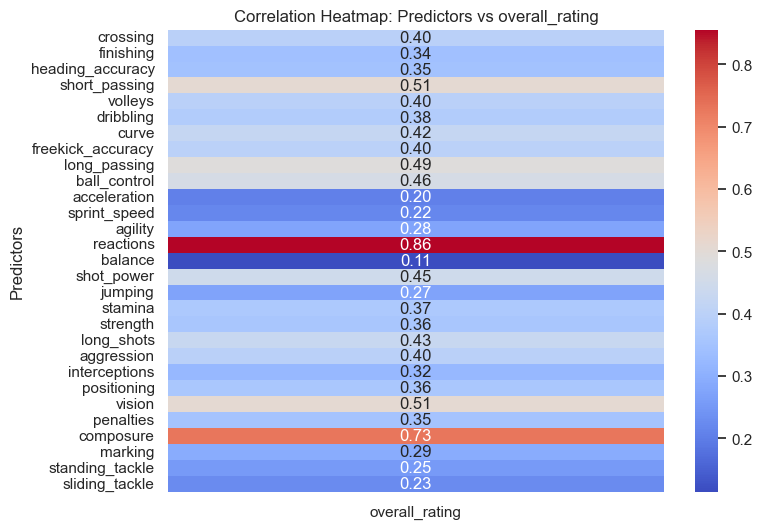

In [99]:
correlation_table = pd.DataFrame(index=predictors, columns=['overall_rating'])

for attribute in predictors:
    atb = pd.DataFrame(fifadata[attribute])
    rating = pd.DataFrame(fifadata["overall_rating"])
    jointDF = pd.concat([rating, atb], axis=1).reindex(rating.index)
    cor = jointDF.corr().iloc[0, 1]
    correlation_table.loc[attribute, 'overall_rating'] = cor


correlation_table['overall_rating'] = correlation_table['overall_rating'].astype(float)

plt.figure(figsize=(8, 6))
sb.heatmap(correlation_table, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation Heatmap: Predictors vs overall_rating')
plt.ylabel('Predictors')
plt.show()


#### It seems that the correlations are not very significant(high) for a majority of attributes

### Let us try to split the dataset based on players' positions to check if the correlations are higher

#### The dataset is updated to just 4 player positions: Attack(ATK), Midfield(MID), Defense(DEF) and Goalkeeper(GK)

In [100]:
fifadata['positions'] = fifadata['positions'].apply(lambda x: x.split(',')[0] if ',' in x else x)

position_mapping = {
    'ST': 'ATK',
    'CF': 'ATK',
    'RW': 'ATK',
    'LW': 'ATK',
    'CM': 'MID',
    'CAM': 'MID',
    'CDM': 'MID',
    'LM': 'MID',
    'RM': 'MID',
    'CB': 'DEF',
    'LB': 'DEF',
    'RB': 'DEF',
    'LWB': 'DEF',
    'RWB': 'DEF', 
}

fifadata['positions'] = fifadata['positions'].replace(position_mapping)
fifadata.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,ATK,Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,MID,Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,MID,France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,ATK,Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,DEF,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


In [101]:
unique_positions = fifadata['positions'].unique()
print(unique_positions)

['ATK' 'MID' 'DEF' 'GK']


In [102]:
p = pd.DataFrame(fifadata["positions"])
p.head()

,positions
0,ATK
1,MID
2,MID
3,ATK
4,DEF


### Splitting the dataset into train and test data in the ratio 75:25

In [103]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

fifadata_train, fifadata_test = train_test_split(fifadata, test_size=0.25)

predictors = pd.DataFrame(fifadata[['crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys', 'dribbling', 'curve', 'freekick_accuracy', 'long_passing', 'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots', 'aggression', 'interceptions', 'positioning', 'vision', 'penalties', 'composure', 'marking', 'standing_tackle', 'sliding_tackle']])
atb_train = fifadata_train[predictors.columns]
atb_test = fifadata_test[predictors.columns]

pos_train = fifadata_train['positions']
pos_test = fifadata_test['positions']



### Using a Decision Tree model to predict the player positions in both the train and test data:

Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9341997772001486

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.8469592336823346



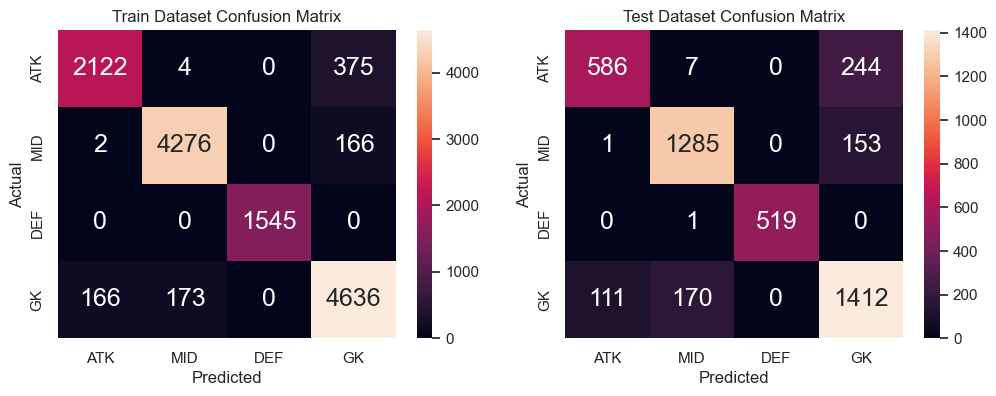

In [104]:
from sklearn.tree import plot_tree

dectree = DecisionTreeClassifier(max_depth=10)  
dectree.fit(atb_train, pos_train)

pos_train_pred = dectree.predict(atb_train)
pos_test_pred = dectree.predict(atb_test)

print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", dectree.score(atb_train, pos_train))
print()

print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", dectree.score(atb_test, pos_test))
print()

f, axes = plt.subplots(1, 2, figsize=(12, 4))


sb.heatmap(confusion_matrix(pos_train, pos_train_pred),
           annot=True, fmt=".0f", annot_kws={"size": 18}, ax=axes[0], 
           xticklabels=['ATK', 'MID', 'DEF', 'GK'], yticklabels=['ATK', 'MID', 'DEF', 'GK'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Train Dataset Confusion Matrix')


sb.heatmap(confusion_matrix(pos_test, pos_test_pred),
           annot=True, fmt=".0f", annot_kws={"size": 18}, ax=axes[1], 
           xticklabels=['ATK', 'MID', 'DEF', 'GK'], yticklabels=['ATK', 'MID', 'DEF', 'GK'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Test Dataset Confusion Matrix')

plt.show()

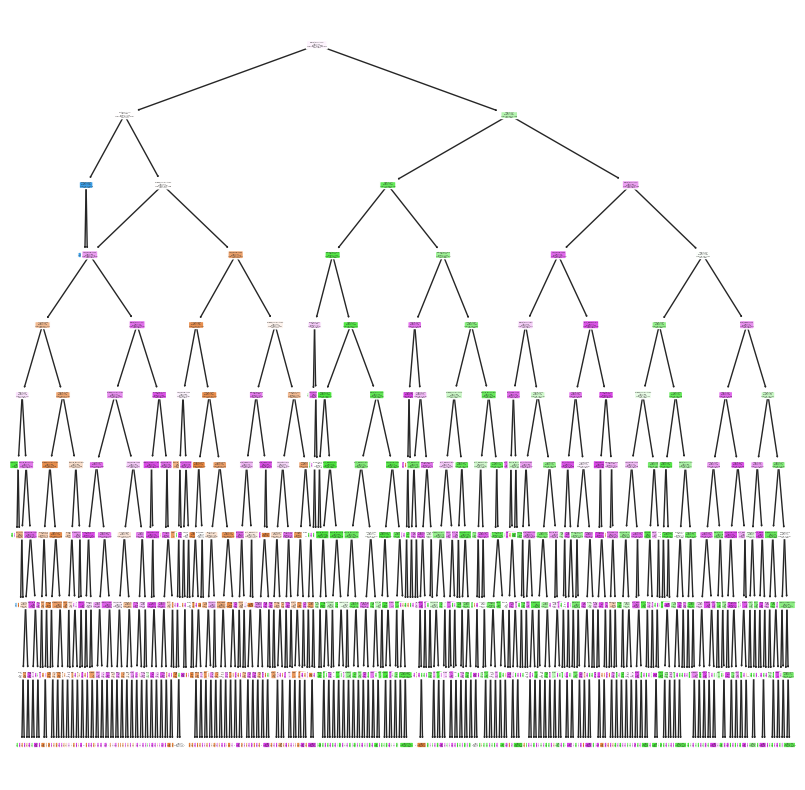

In [105]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


plt.figure(figsize=(10,10))
plot_tree(dectree, filled=True, rounded=True, 
          feature_names=predictors.columns.tolist(),  
          class_names=dectree.classes_.tolist())  
plt.show()


### Using a Random Forest Classifier model to predict the player positions of both train and test data:

Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.9999257333828444

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.8877255513477389



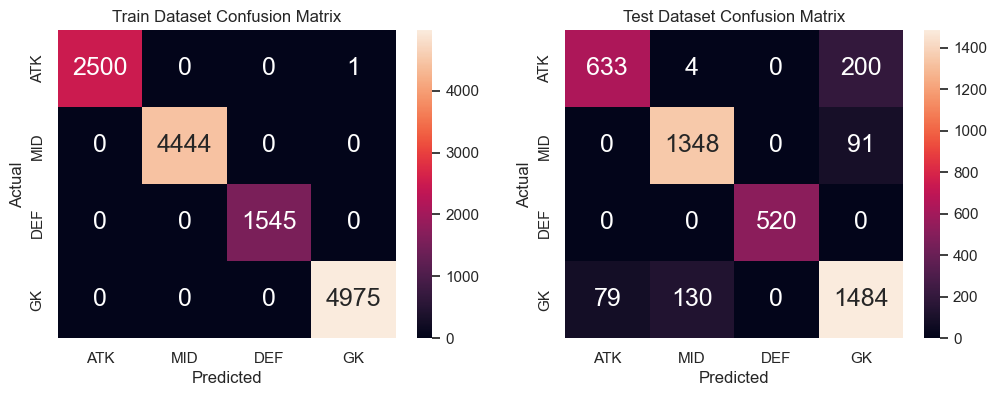

In [106]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(atb_train, pos_train)


train_predictions = rf_classifier.predict(atb_train)
test_predictions = rf_classifier.predict(atb_test)

print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", accuracy_score(pos_train, train_predictions))
print()

print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", accuracy_score(pos_test, test_predictions))
print()

f, axes = plt.subplots(1, 2, figsize=(12, 4))

sb.heatmap(confusion_matrix(pos_train, train_predictions),
           annot=True, fmt=".0f", annot_kws={"size": 18}, ax=axes[0], 
           xticklabels=['ATK', 'MID', 'DEF', 'GK'], yticklabels=['ATK', 'MID', 'DEF', 'GK'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Train Dataset Confusion Matrix')


sb.heatmap(confusion_matrix(pos_test, test_predictions),
           annot=True, fmt=".0f", annot_kws={"size": 18}, ax=axes[1], 
           xticklabels=['ATK', 'MID', 'DEF', 'GK'], yticklabels=['ATK', 'MID', 'DEF', 'GK'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Test Dataset Confusion Matrix')

plt.show()

#### It seems that the Random Forest is more accurate than the decision tree in predicting player positions for both train (1>0.94) and test data (0.88>0.83). Hence, we would be choosing Random Forest Classifier Model for prediction

### Instead of finding the correlation between the predictors and overall ratings for the data as a whole, we created a function that find correlation between predictors and overall ratings based on different players' position. The function that return an array of predictors that have over 0.8 correlation with the overall_ratings with respect to the position.

In [126]:
def Find_correlation(df, predictors, position):
    df_filtered = df[df["positions"] == position]
    rating = pd.DataFrame(df_filtered['overall_rating'])
    correlation_data = {}

    for attribute in predictors:
        atb = pd.DataFrame(df_filtered[attribute])
        jointDF = pd.concat([rating, atb], axis=1).reindex(rating.index)
        cor = jointDF.corr().iloc[0, 1]
        correlation_data[attribute] = cor

    correlation_table = pd.DataFrame.from_dict(correlation_data, orient='index', columns=['overall_rating'])
    correlation_table.index.name = 'Predictors'
    
    plt.figure(figsize=(8, 6))
    sb.heatmap(correlation_table, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
    title = f'Correlation Heatmap for {position}: Predictors vs overall_rating'
    plt.title(title)
    plt.ylabel('Predictors')
    plt.show()
    
    top_predictors = [predictor for predictor, correlation in correlation_data.items() if correlation > 0.8]
    
    print("Top predictors with correlation > 0.8:", top_predictors)
    
    return top_predictors


In [127]:
predictors = pd.DataFrame(fifadata[['crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys', 'dribbling', 'curve', 'freekick_accuracy', 'long_passing', 'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots', 'aggression', 'interceptions', 'positioning', 'vision', 'penalties', 'composure', 'marking', 'standing_tackle', 'sliding_tackle']])



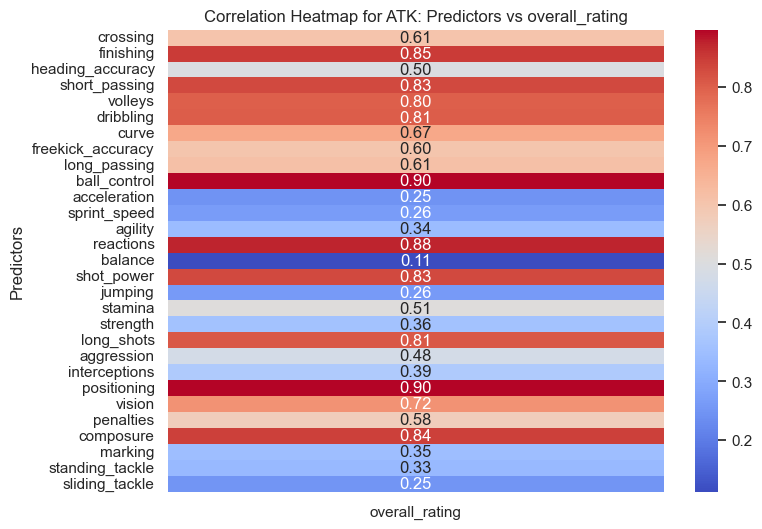

Top predictors with correlation > 0.8: ['finishing', 'short_passing', 'volleys', 'dribbling', 'ball_control', 'reactions', 'shot_power', 'long_shots', 'positioning', 'composure']


In [128]:
pred_atk = Find_correlation(fifadata_train, predictors, "ATK")

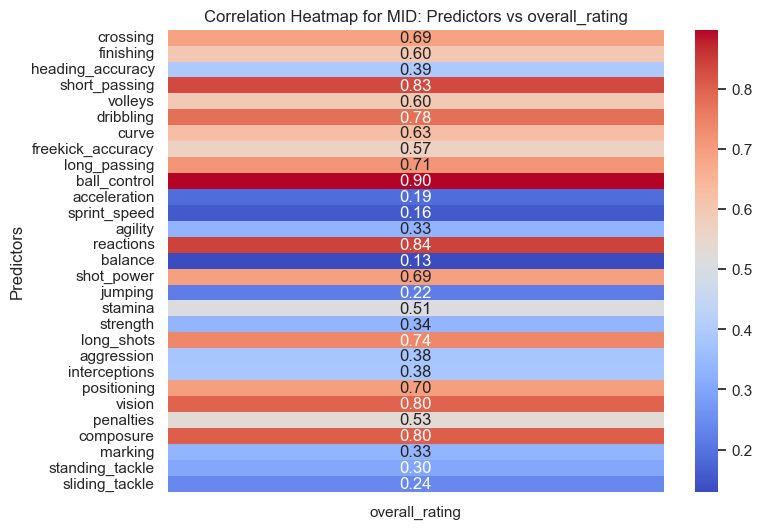

Top predictors with correlation > 0.8: ['short_passing', 'ball_control', 'reactions', 'composure']


In [130]:
pred_mid = Find_correlation(fifadata_train, predictors, "MID")

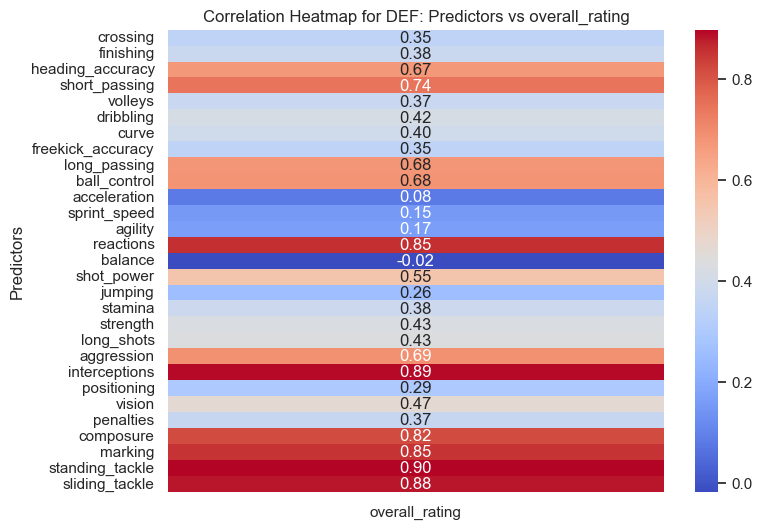

Top predictors with correlation > 0.8: ['reactions', 'interceptions', 'composure', 'marking', 'standing_tackle', 'sliding_tackle']


In [131]:
pred_def = Find_correlation(fifadata_train, predictors, "DEF")



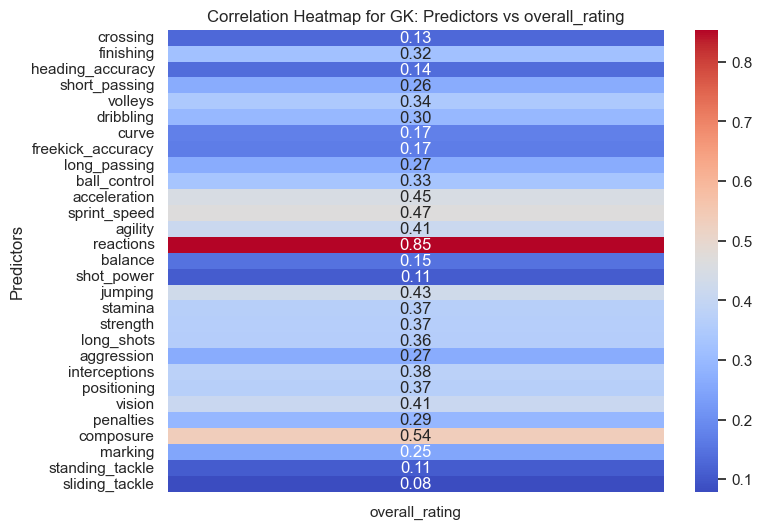

Top predictors with correlation > 0.8: ['reactions']


In [132]:
pred_gk = Find_correlation(fifadata_train, predictors, "GK")

### We will try using two different regression functions. Both functions take the position and the array of predictors that have higher correlation than 0.8 with respect to the positions. The array of predictors will be used to predict the ratings of players of the position.

### The first one is multi linear regression, where it take the array of predictors and position as parameters, allowing the prediction of the dependent variable based on the values of multiple independent variables.

In [133]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def multiReg(predictors, pos):
    fifadata_train_pos = fifadata_train[fifadata_train["positions"] == pos]
    atb_train = fifadata_train_pos[predictors]
    rating_train = fifadata_train_pos['overall_rating']

    fifadata_test_pos = fifadata_test[fifadata_test["positions"] == pos]
    atb_test = fifadata_test_pos[predictors]
    rating_test = fifadata_test_pos['overall_rating']

    model = LinearRegression()
    model.fit(atb_train, rating_train)

    rating_pred_train = model.predict(atb_train)
    rating_pred_test = model.predict(atb_test)

    mse_train = mean_squared_error(rating_train, rating_pred_train)
    mse_test = mean_squared_error(rating_test, rating_pred_test)

    r_squared_train = model.score(atb_train, rating_train)
    r_squared_test = model.score(atb_test, rating_test)

    print("Goodness of Fit of Model \tTrain Dataset")
    print("Explained Variance (R^2) \t:", r_squared_train)
    print("Mean Squared Error (MSE) \t:", mse_train)
    print()
    print("Goodness of Fit of Model \tTest Dataset")
    print("Explained Variance (R^2) \t:", r_squared_test)
    print("Mean Squared Error (MSE) \t:", mse_test)
    
    f, axes = plt.subplots(1, 2, figsize=(24, 12))
    axes[0].scatter(rating_train, rating_pred_train, color="blue")
    axes[0].plot(rating_train, rating_train, 'w-', linewidth=1)
    axes[0].set_xlabel("True values of the Response Variable (Train)")
    axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
    axes[1].scatter(rating_test, rating_pred_test, color="green")
    axes[1].plot(rating_test, rating_test, 'w-', linewidth=1)
    axes[1].set_xlabel("True values of the Response Variable (Test)")
    axes[1].set_ylabel("Predicted values of the Response Variable (Test)")
    plt.show()
    
    return model

### The second one is by adding the up the stats of the attributes in the array of predictors of the player based on positions, then the total stats is used to predict the overall ratings of the player.

In [134]:
def LinReg_total(predictors, pos):
    fifadata_train_pos = fifadata_train[fifadata_train["positions"] == pos] 
    fifadata_test_pos = fifadata_test[fifadata_test["positions"] == pos] 
    
    total_train = fifadata_train_pos[predictors].sum(axis=1)
    total_test = fifadata_test_pos[predictors].sum(axis=1)

    rating_train = fifadata_train_pos['overall_rating'] 
    rating_test = fifadata_test_pos['overall_rating'] 

    model = LinearRegression()
    model.fit(total_train.values.reshape(-1, 1), rating_train)

    rating_pred_train = model.predict(total_train.values.reshape(-1, 1))
    rating_pred_test = model.predict(total_test.values.reshape(-1, 1))

    mse_train = mean_squared_error(rating_train, rating_pred_train)
    mse_test = mean_squared_error(rating_test, rating_pred_test)

    r_squared_train = model.score(total_train.values.reshape(-1, 1), rating_train)
    r_squared_test = model.score(total_test.values.reshape(-1, 1), rating_test)

    print("Goodness of Fit of Model \tTrain Dataset")
    print("Explained Variance (R^2) \t:", r_squared_train)
    print("Mean Squared Error (MSE) \t:", mse_train)
    print()
    print("Goodness of Fit of Model \tTest Dataset")
    print("Explained Variance (R^2) \t:", r_squared_test)
    print("Mean Squared Error (MSE) \t:", mse_test)

    f, axes = plt.subplots(1, 2, figsize=(24, 12))
    axes[0].scatter(rating_train, rating_pred_train, color="blue")
    axes[0].plot(rating_train, rating_train, 'w-', linewidth=1)
    axes[0].set_xlabel("True values of the Response Variable (Train)")
    axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
    axes[1].scatter(rating_test, rating_pred_test, color="green")
    axes[1].plot(rating_test, rating_test, 'w-', linewidth=1)
    axes[1].set_xlabel("True values of the Response Variable (Test)")
    axes[1].set_ylabel("Predicted values of the Response Variable (Test)")
    plt.show()


Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.95185035471946
Mean Squared Error (MSE) 	: 2.4879472903176802

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.9438295499740997
Mean Squared Error (MSE) 	: 2.7932879778312008


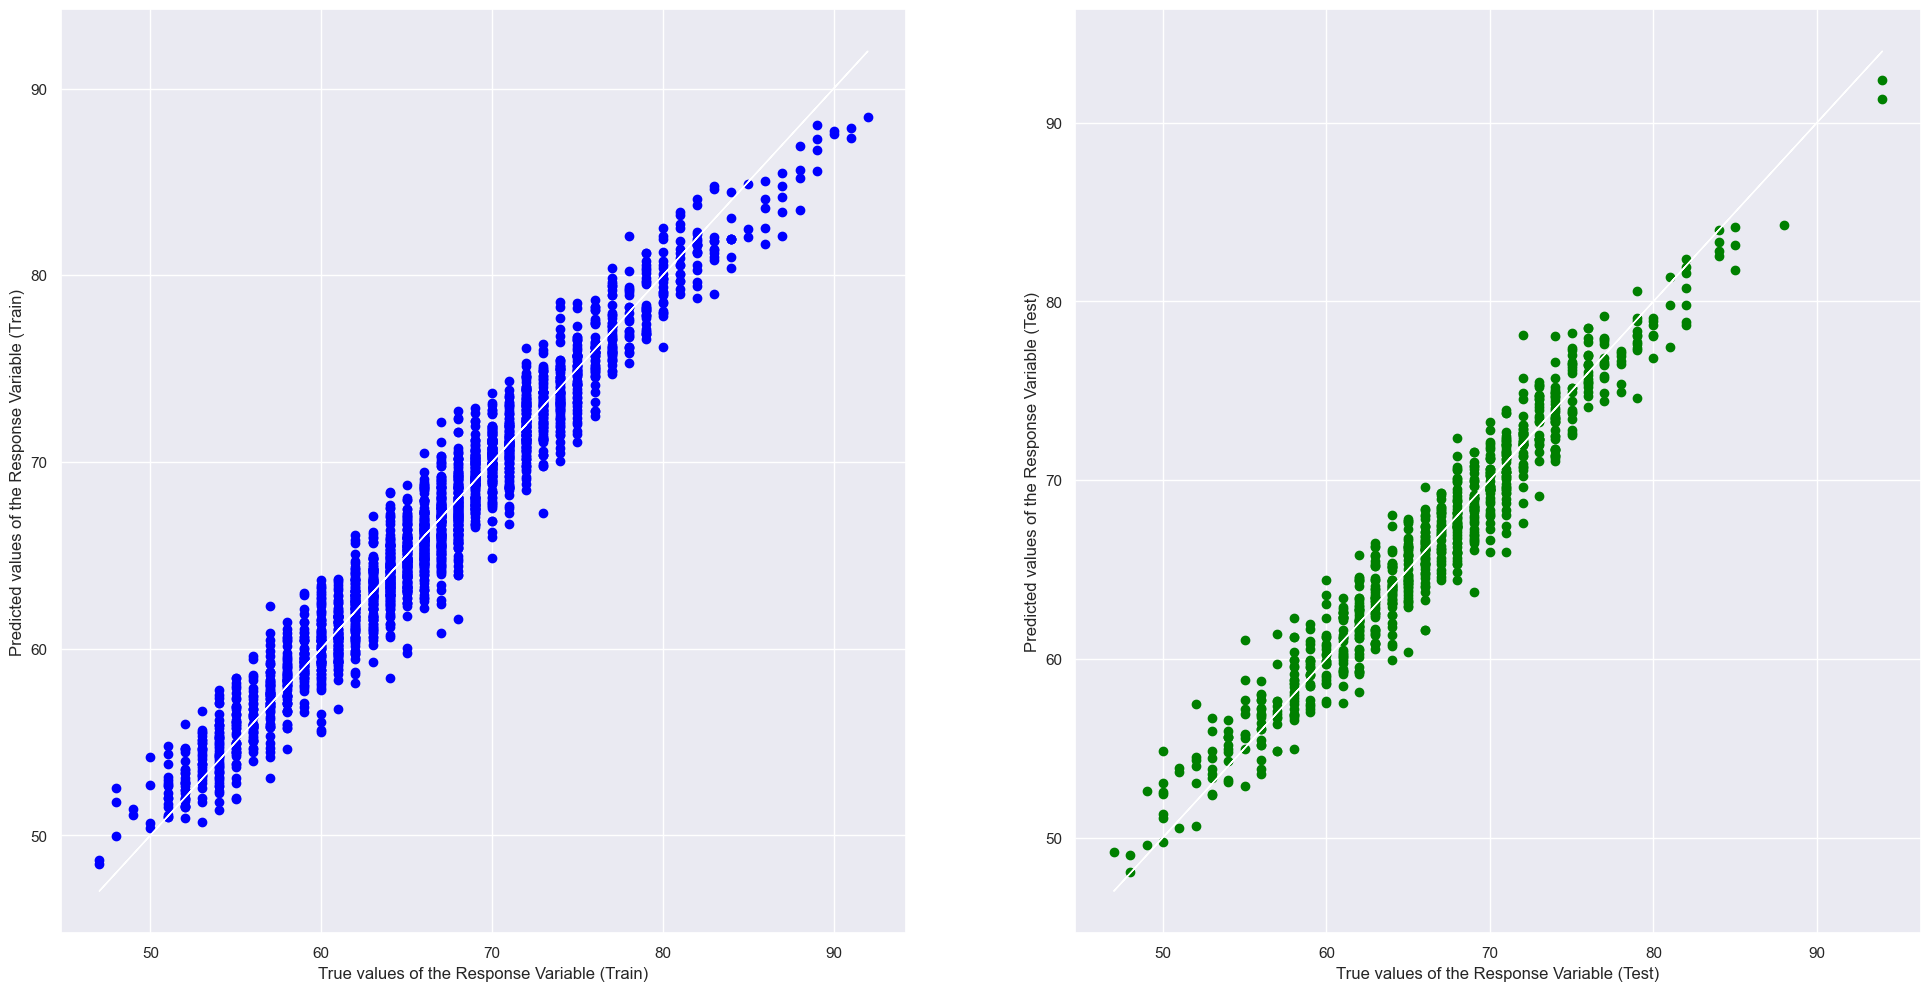

In [135]:
LinReg_total(pred_atk,"ATK")

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.8794960007707008
Mean Squared Error (MSE) 	: 5.747195900603588

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.8895107719750847
Mean Squared Error (MSE) 	: 5.4318252727322065


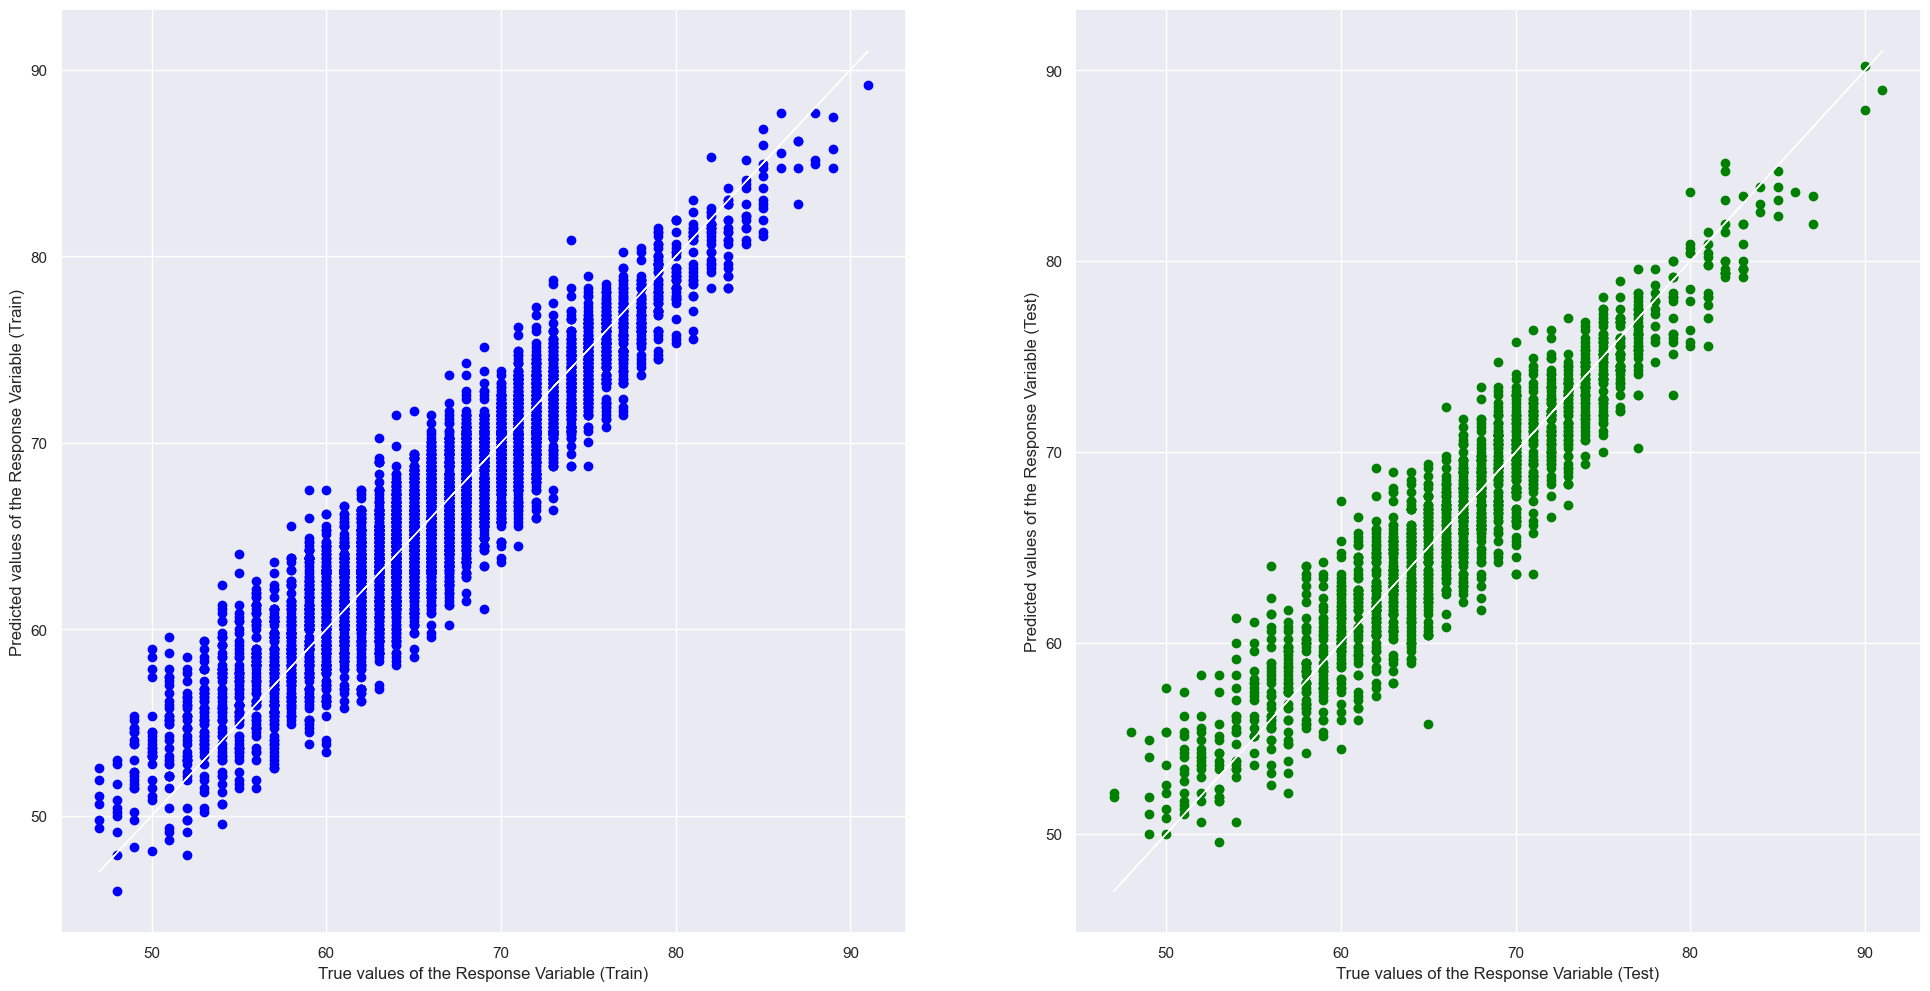

In [136]:
LinReg_total(pred_mid,"MID")

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.9309905632182739
Mean Squared Error (MSE) 	: 2.9398662510334765

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.929791044650476
Mean Squared Error (MSE) 	: 2.978527372137471


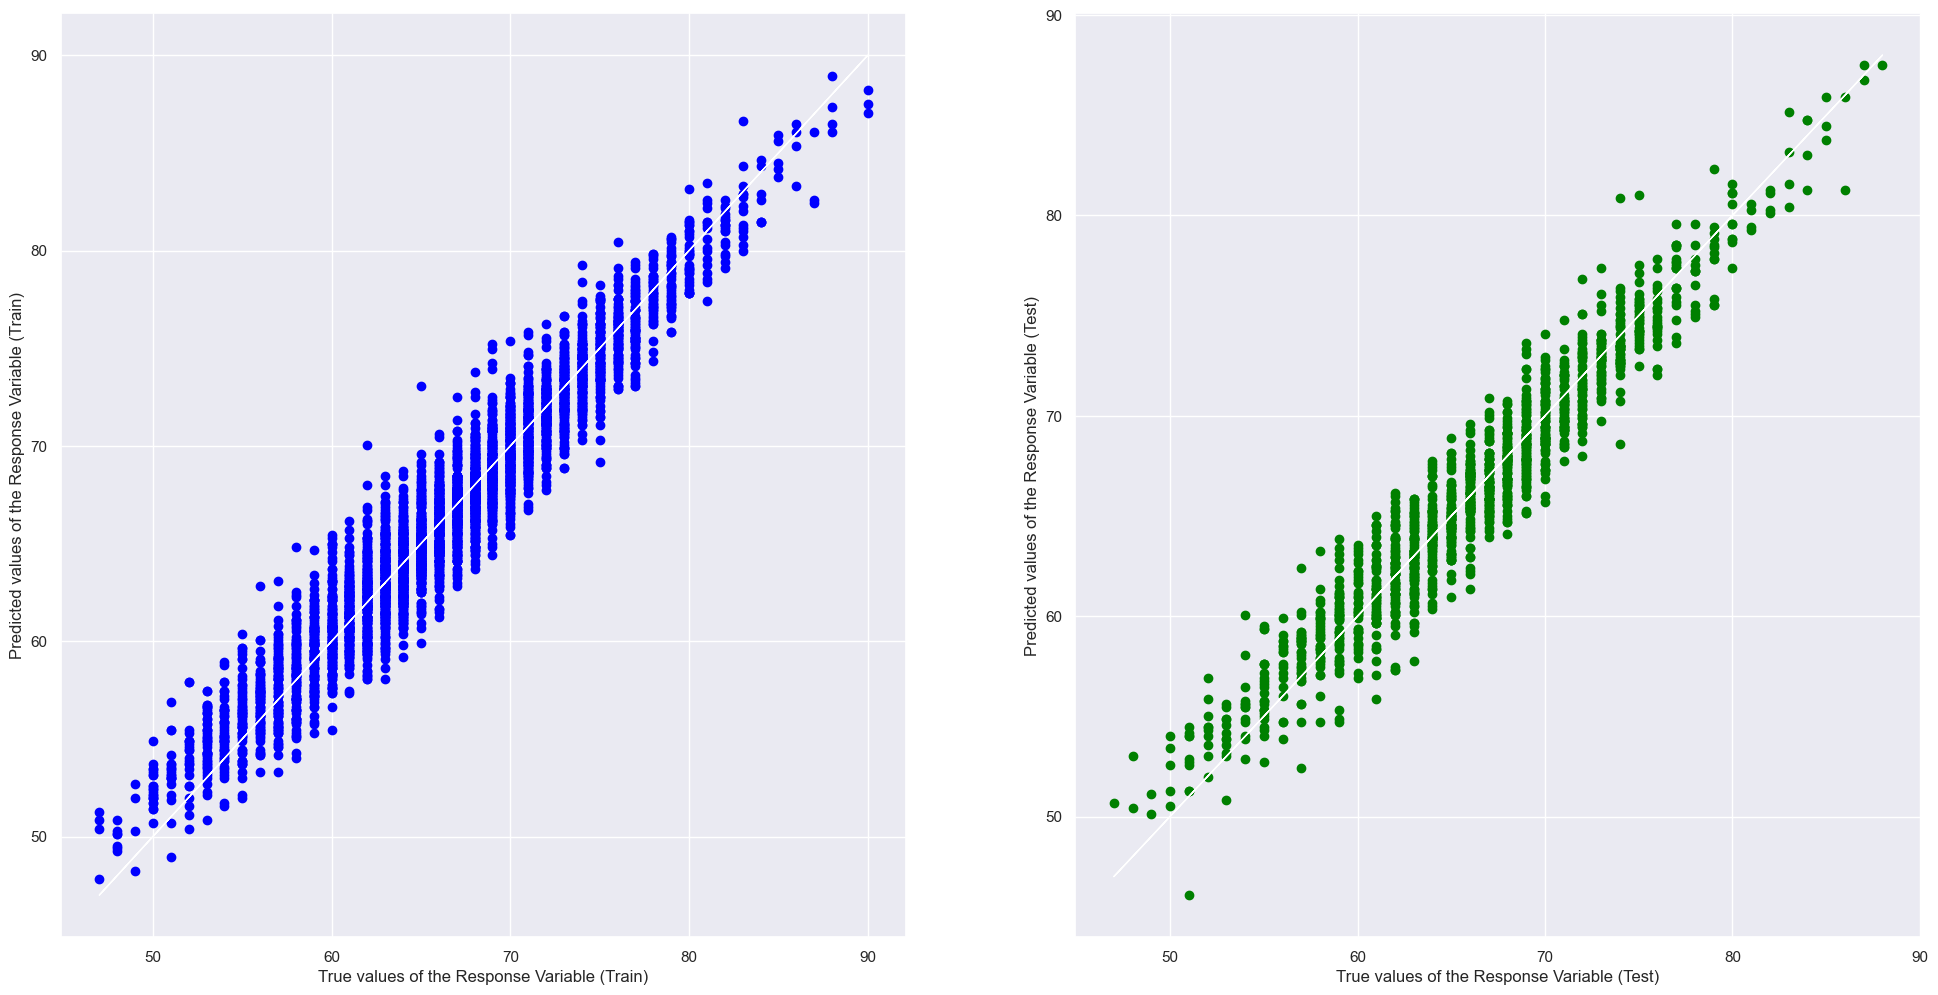

In [137]:
LinReg_total(pred_def,"DEF")

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.72888568978429
Mean Squared Error (MSE) 	: 15.940200070406915

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.7473946270756068
Mean Squared Error (MSE) 	: 14.904680153942621


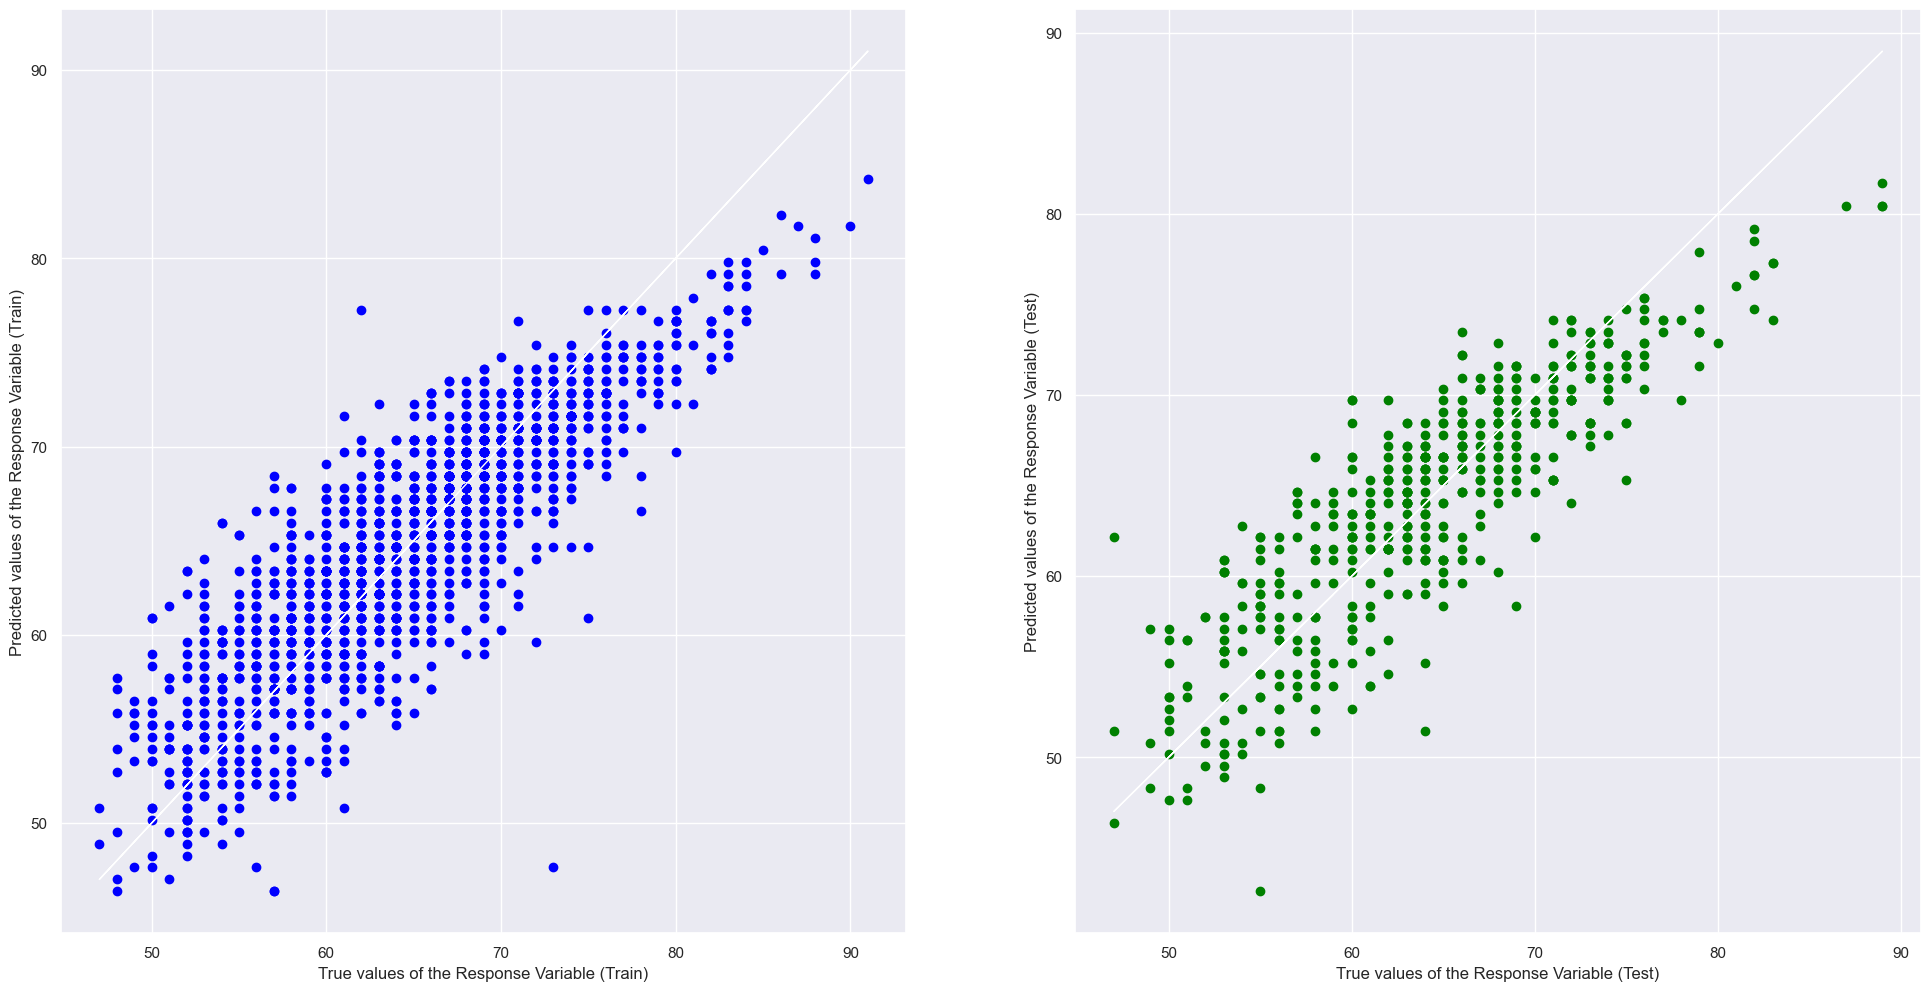

In [138]:
LinReg_total(pred_gk,"GK")

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.9662558429501505
Mean Squared Error (MSE) 	: 1.7435992229450057

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.9639012293063275
Mean Squared Error (MSE) 	: 1.7951478428003675


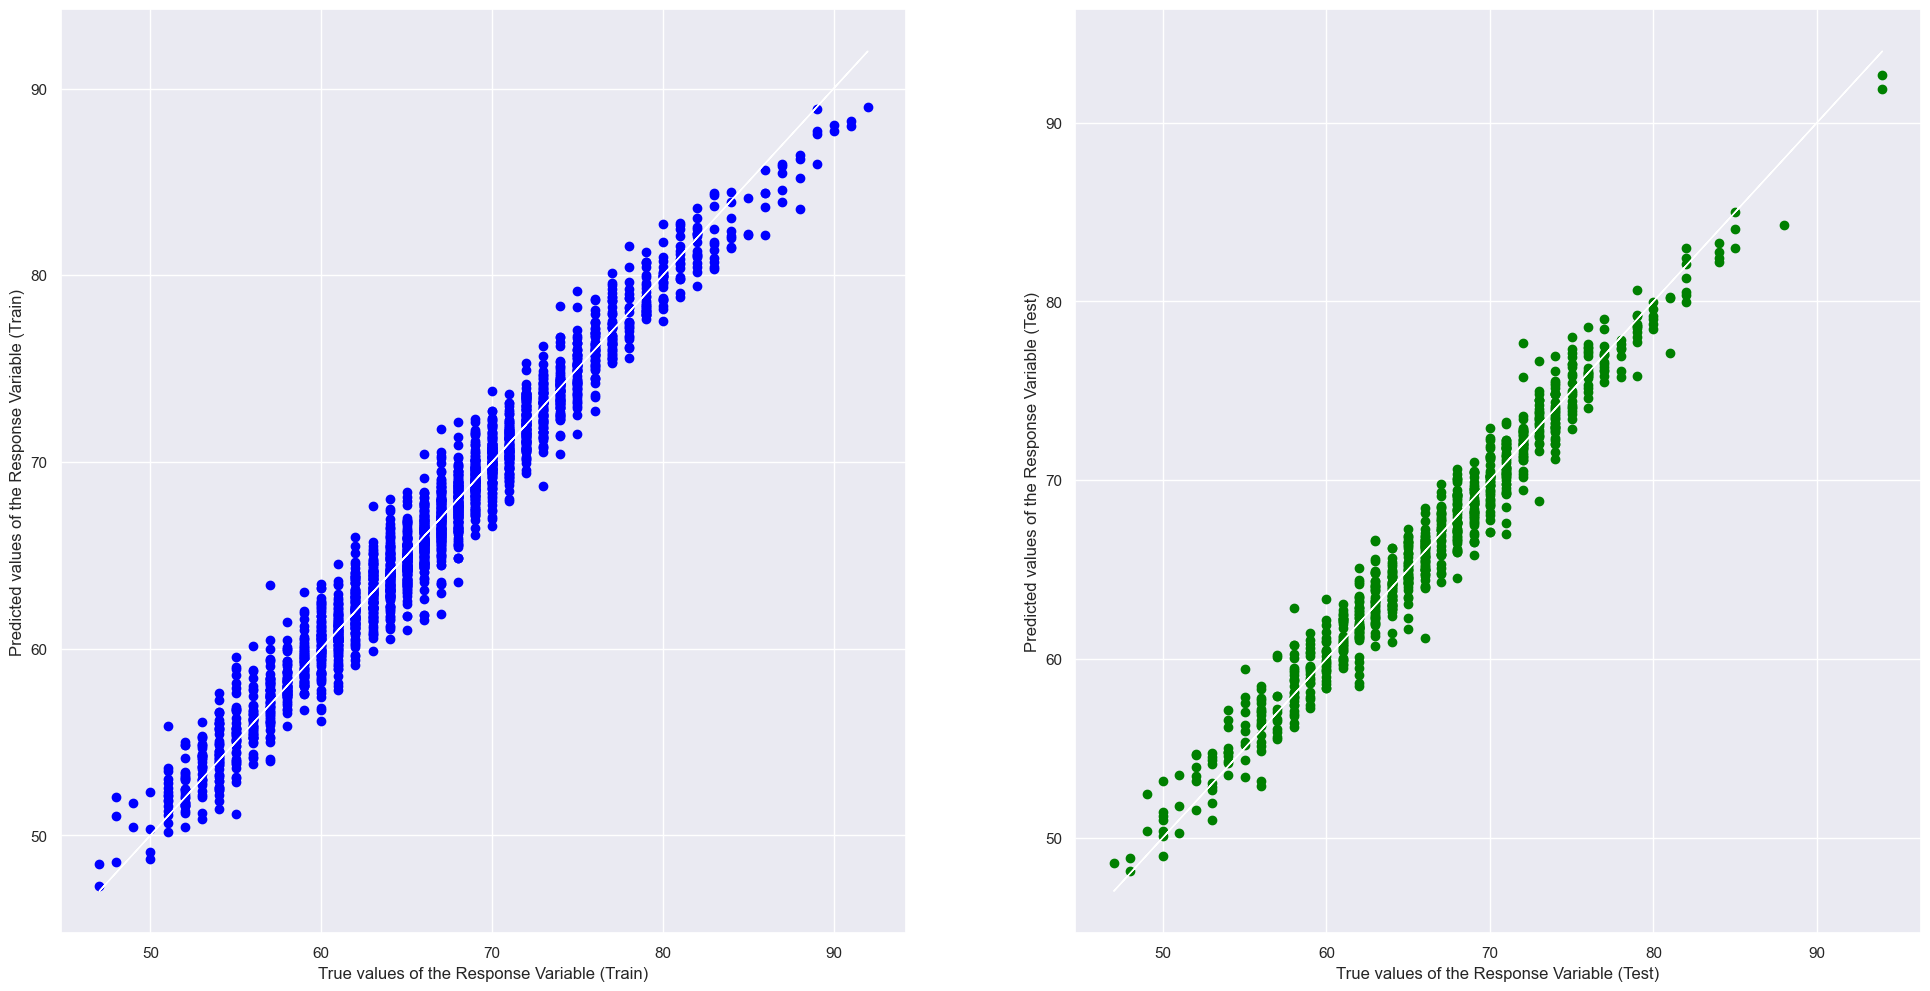

In [139]:
model_atk = multiReg(pred_atk, "ATK")

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.9001694997467373
Mean Squared Error (MSE) 	: 4.7612149429083575

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.9038903726472518
Mean Squared Error (MSE) 	: 4.724901351377075


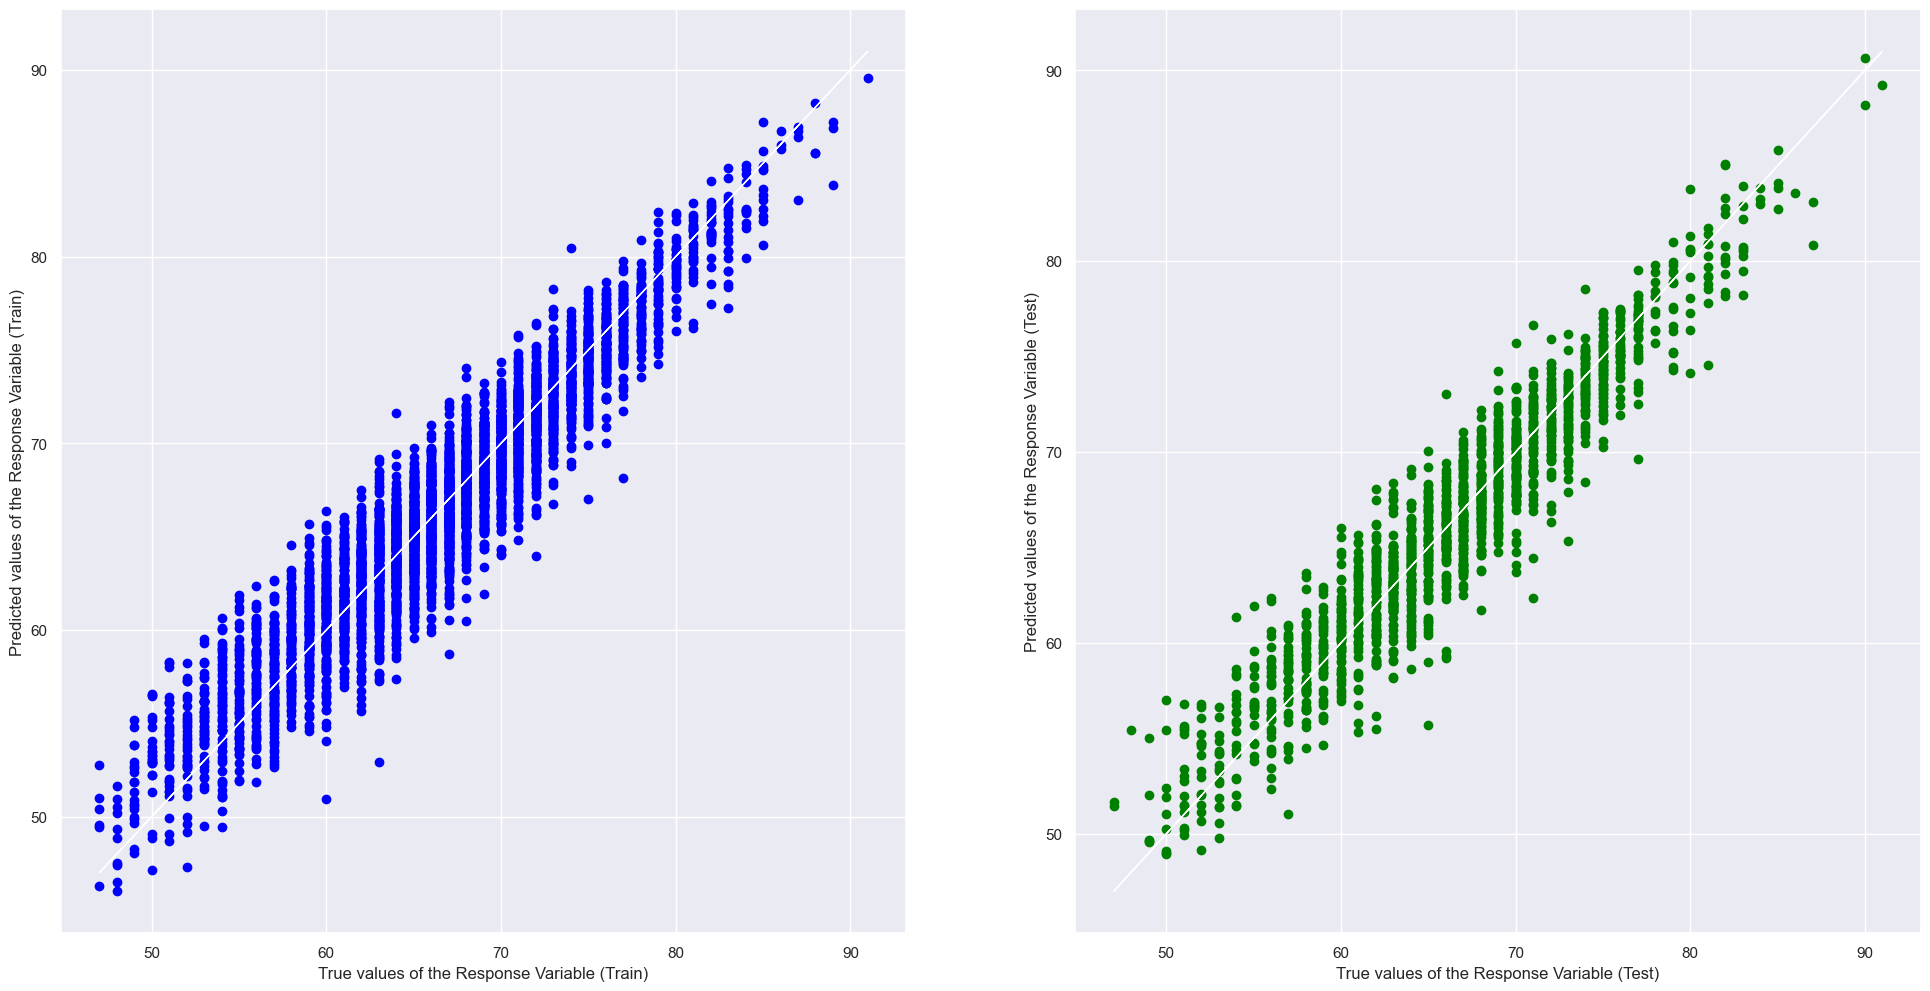

In [140]:
model_mid = multiReg(pred_mid, "MID")

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.9332935724201167
Mean Squared Error (MSE) 	: 2.841755915055341

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.9318621012016647
Mean Squared Error (MSE) 	: 2.8906653807967646


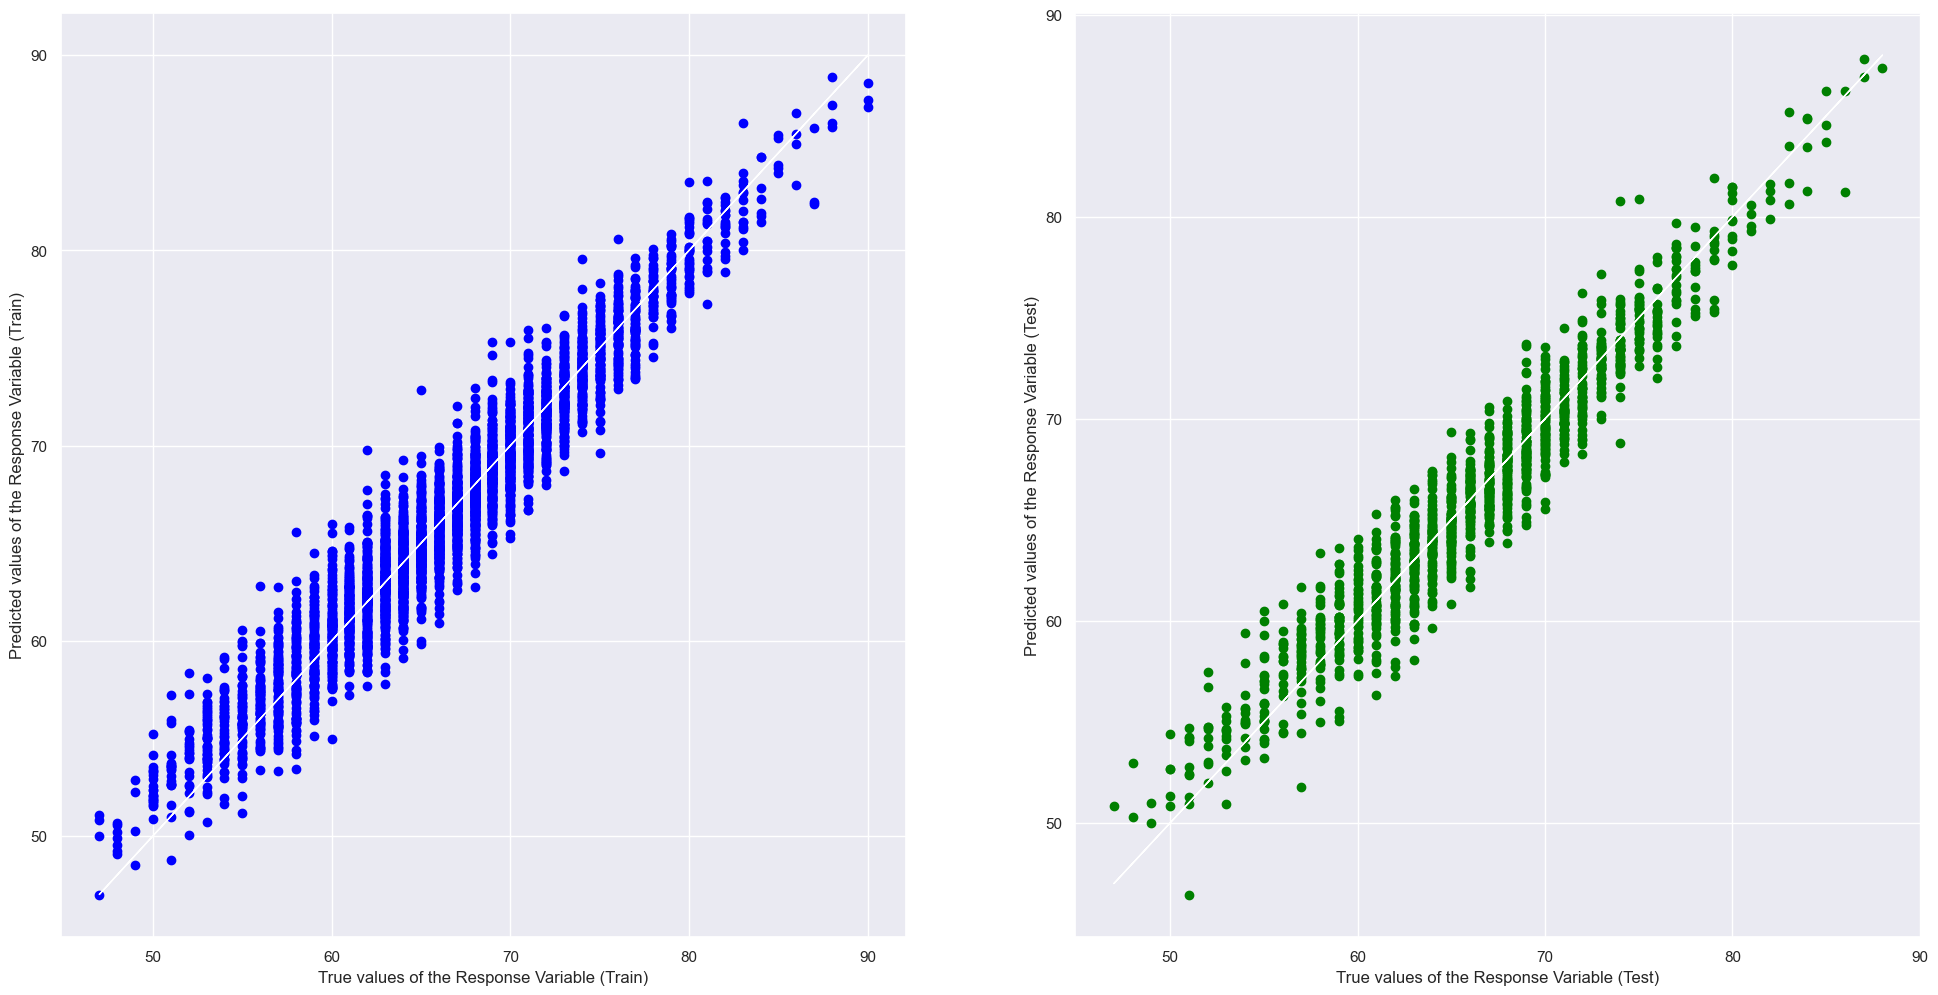

In [141]:
model_def = multiReg(pred_def, "DEF")

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.72888568978429
Mean Squared Error (MSE) 	: 15.940200070406915

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.7473946270756068
Mean Squared Error (MSE) 	: 14.904680153942621


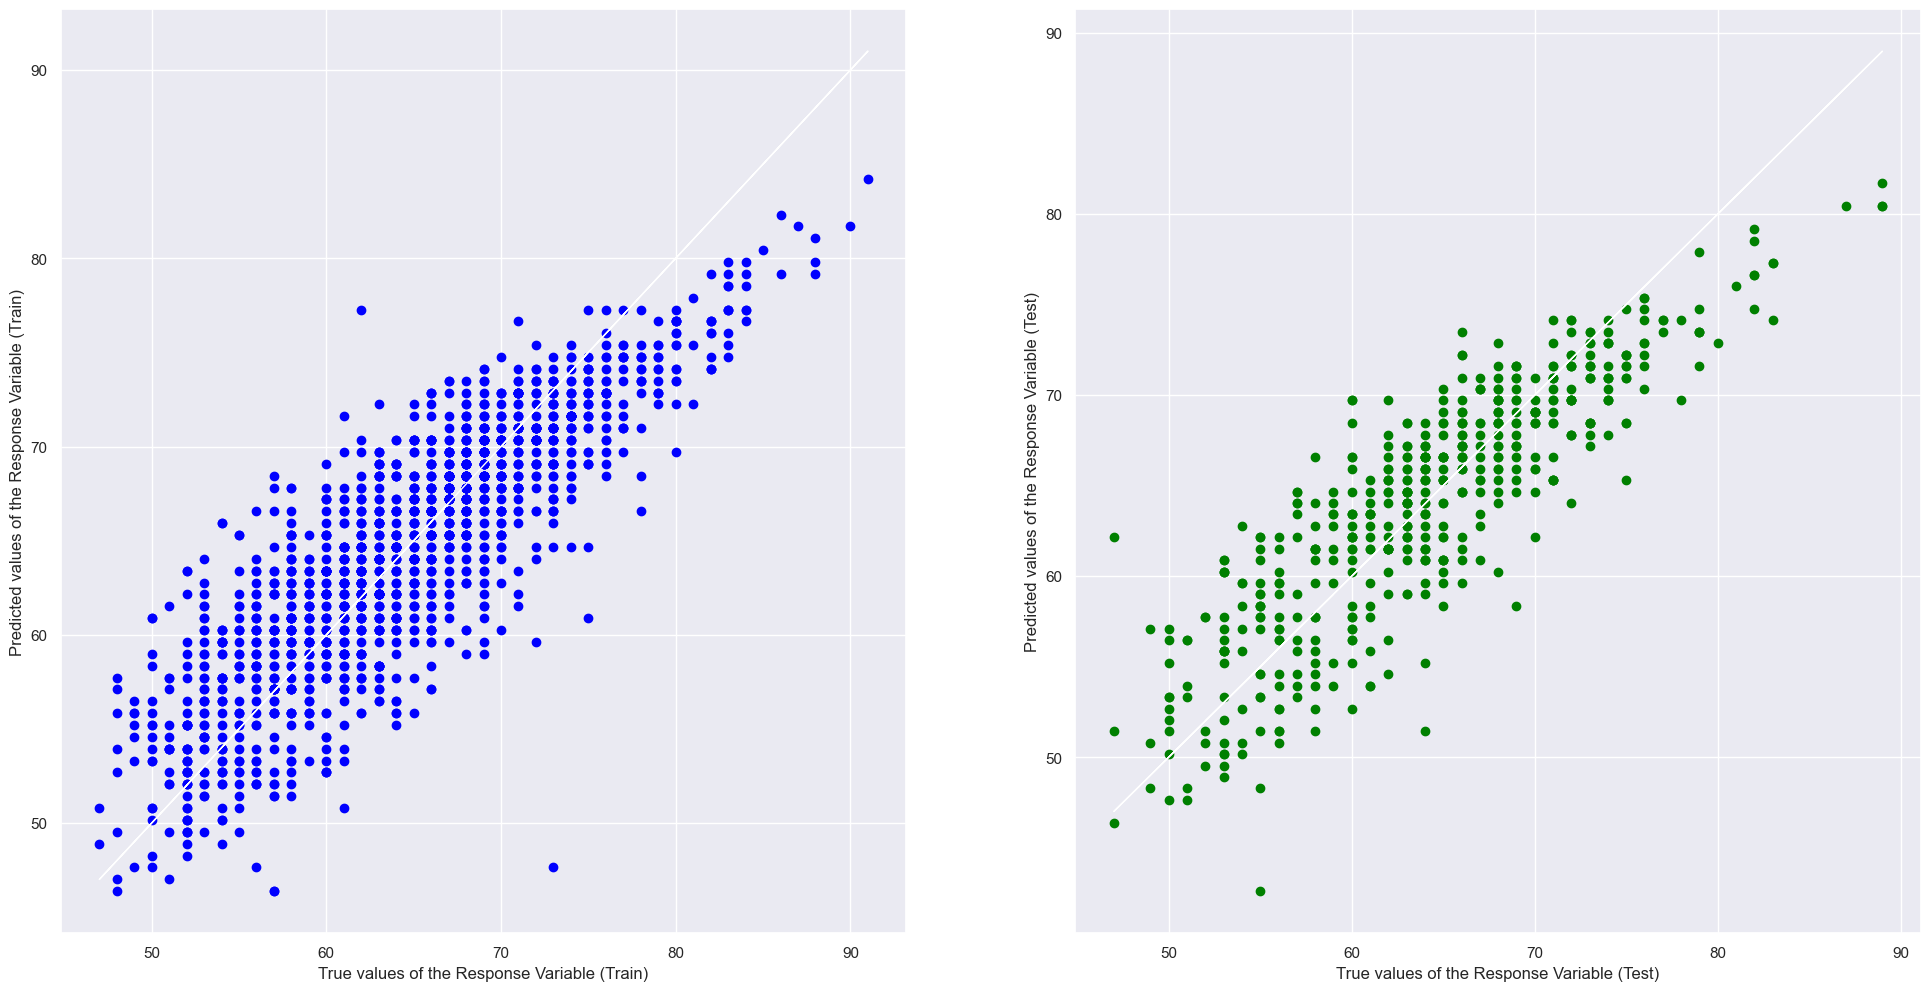

In [142]:
model_gk = multiReg(pred_gk, "GK")

### Based on the goodness of fit of two models for each positions, we can see that the Multi linear regression model is better than the linear regression model with total stats.

### We then create an identical data frame to the original data, then use the predicted positions from the random forest to  replace the actual positions

In [143]:
fifa_pos_pred = fifadata_test.copy()

fifa_pos_pred['positions'] = test_predictions

### Then we use the models with respect to the positions to predict to overall ratings based on the predicted positions. The predicted overall ratings is then compared with the actual overall ratings to calculate the mean squared error and explained variance.

In [144]:
models_info = [('ATK', model_atk, pred_atk),
               ('MID', model_mid, pred_mid),
               ('DEF', model_def, pred_def),
               ('GK', model_gk, pred_gk)]

for models in models_info:
    pos_filter = fifa_pos_pred['positions'] == models[0]
    if np.any(pos_filter):
        fifa_pos_pred.loc[pos_filter, 'predicted_rating'] = models[1].predict(fifa_pos_pred.loc[pos_filter, models[2]])

mse = mean_squared_error(fifa_pos_pred['overall_rating'], fifa_pos_pred['predicted_rating'])
r2 = r2_score(fifa_pos_pred['overall_rating'], fifa_pos_pred['predicted_rating'])

print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")

Mean Squared Error (MSE): 4.751360929086864
R² Score: 0.9024659150235612
